<a href="https://colab.research.google.com/github/nika19du/LangGraph-Agent-Workflows/blob/master/Multi_Agent_AI_Developer_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install dependentcies

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-anthropic langchain-community wikipedia arxiv tavily-python

In [2]:
!pip install -q langchain-tavily

In [3]:
!pip install -q chromadb langchain-chroma

## Imports

In [4]:
import os
import subprocess

from collections import Counter
from html import escape
from IPython.display import Image, HTML, display
from google.colab import userdata
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, TypedDict, Literal
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.runnables import Runnable

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_core.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, Interrupt, Send, interrupt
from langchain.agents import create_agent

from langchain_tavily import TavilySearch


/tmp/ipykernel_40762/321712361.py:19: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


## API Keys

In [5]:
openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))

anthropic_api_key = userdata.get("ANTHROPIC_API_KEY")

tavily_api_key = userdata.get("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = tavily_api_key

## Model Configuration

- The coding model generates and revises code.
- The reviewer model independently evaluates proposed implementations.

In [6]:
coding_model = ChatOpenAI(
    model = "gpt-5.6-luna",
    api_key=openai_api_key,
    reasoning_effort="none"
)

review_model=ChatAnthropic(
    model="claude-sonnet-4-6",
    api_key= anthropic_api_key
)

## Knowledge Base & RAG

In [7]:
KNOWLEDGE_FILE = Path(
    "/content/developer_assistant_knowledge.md"
)

if not KNOWLEDGE_FILE.exists():
    raise FileNotFoundError(
        "Upload developer_assistant_knowledge.md "
        "to the Colab runtime before running this cell."
    )

loader = TextLoader(
    str(KNOWLEDGE_FILE),
    encoding="utf-8"
)

documents = loader.load()

print(
    f"Loaded documents: {len(documents)}"
)

Loaded documents: 1


In [8]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=[
        "\n## ",
        "\n### ",
        "\n\n",
        "\n",
        " ",
        ""
    ]
)

chunks = text_splitter.split_documents(documents)

print(f"Documents: {len(documents)}")

print(f"Chunks: {len(chunks)}")

Documents: 1
Chunks: 23


## Embeddings

Each knowledge-base chunk is converted into a numerical embedding.

Embedding make it possible to compare the semantic meaning of a user query with the stored documentation.

In [9]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

## Chroma Vector Store

The document chunks and their embeddings are stored in Chroma.

Chroma provides semantic search over the internal developer documentation.

In [10]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="developer_assistant_knowledge"
)

print(
    f"Indexed chunks: {len(chunks)}"
)

Indexed chunks: 23


## Retriever

The retriever returns the most semantically relevant knowledge-base chunk for a query.

In [11]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 4
    }
)

## Internal Knowledge Tool

The internal search tool exposes the Chroma retriever to the agent.

It is used when a question depends on project-specific engineering guidelines or internal documentation.  

In [12]:
@tool
def search_knowledge_base(query: str) -> str:
    """
    Search the internal developer knowledge base.

    Use this tool for project-specific engineering guidelines,
    coding standards, testing conventions, architecture,
    error-handling rules, and internal developmennt policies.

    Args:
        query: Semantic search query.

    Returns:
        Relevant passages from the internal knowledge base.
    """

    documents = retriever.invoke(query)

    if not documents:
        return (
            "No relevant information was found "
            "in the internal knowledge base."
        )

    results = []

    for index, document in enumerate(documents, start =1):
        results.append(
            f"""
          Result {index}
          ---------
          {document.page_content}
          """.strip()
        )

    return "\n\n".join(results)


## Shared Utilities

In [13]:
def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format="png"))

def print_tool_usage(conversation: List[BaseMessage]):
    tool_counts = Counter()

    for message in conversation:
        if isinstance(message, AIMessage):
            for tool_call in message.tool_calls:
                tool_counts[tool_call["name"]] += 1

    if not tool_counts:
        print("No tools were called.")
        return

    print("Tool Usage")
    print("----------")

    for tool_name, count in tool_counts.items():
        print(f"{tool_name}: {count}")

def print_interrupts(interrupts: List[Interrupt]) -> None:
    for interrupt_item in interrupts:
        value = interrupt_item.value

        workflow_status = str(value.get("workflow_status", ""))

        # 1. Missing file path
        if workflow_status == "waiting_for_file_path":
            message = escape(str(value.get("message", "")))

            display(
                HTML(
                    f"""
                    <div>
                        <h3>Input Required</h3>

                        <p>{message}</p>

                        <p>
                            <strong>Workflow Status:</strong>
                            waiting_for_file_path
                        </p>

                        <p>
                            Provide a valid file path,
                            for example:
                            <code>/content/example.py</code>
                        </p>
                    </div>
                    """
                )
            )

        # 2. Human code review / approval
        elif workflow_status == "pending_human_approval":
            message = escape(
                str(value.get("message", ""))
            )

            proposed_content = escape(str(value.get("proposed_content", "")))

            review = value.get("review") or {}

            # Overall review
            status = escape(str(review.get("status", "")))

            score = escape(str(review.get("score", "")))

            issues = escape(str(review.get("issues", [])))

            feedback = escape(str(review.get("feedback", "")))

            # Individual review criteria
            correctness = escape(str(review.get("correctness", "")))

            edge_cases = escape(str(review.get("edge_cases", "")))

            readability = escape(str(review.get("readability", "")))

            maintainability = escape(str(review.get("maintainability", "")))

            requirements_met = escape(str(review.get("requirements_met", "")))

            # Revision counters
            ai_revision_count = escape(
                str(
                    value.get(
                        "ai_revision_count",
                        0
                    )
                )
            )

            human_revision_count = escape(
                str(
                    value.get(
                        "human_revision_count",
                        0
                    )
                )
            )

            display(
                HTML(
                    f"""
                    <div>
                        <h3>Human Review Required</h3>

                        <p>{message}</p>

                        <h4>Proposed Content</h4>

                        <pre><code>{proposed_content}</code></pre>

                        <p>
                            <strong>Workflow Status:</strong>
                            pending_human_approval
                        </p>

                        <h4>AI Review</h4>

                        <p>
                            <strong>AI Review Status:</strong>
                            {status}
                        </p>

                        <p>
                            <strong>Overall Score:</strong>
                            {score}/10
                        </p>

                        <h4>Review Criteria</h4>

                        <p>
                            <strong>Correctness:</strong>
                            {correctness}/10
                        </p>

                        <p>
                            <strong>Edge Cases:</strong>
                            {edge_cases}/10
                        </p>

                        <p>
                            <strong>Readability:</strong>
                            {readability}/10
                        </p>

                        <p>
                            <strong>Maintainability:</strong>
                            {maintainability}/10
                        </p>

                        <p>
                            <strong>Requirements Met:</strong>
                            {requirements_met}
                        </p>

                        <h4>Review Details</h4>

                        <p>
                            <strong>Issues:</strong>
                            {issues}
                        </p>

                        <p>
                            <strong>Feedback:</strong>
                            {feedback}
                        </p>

                        <h4>Revision History</h4>

                        <p>
                            <strong>AI revisions:</strong>
                            {ai_revision_count}
                        </p>

                        <p>
                            <strong>Human revisions:</strong>
                            {human_revision_count}
                        </p>

                        <p>
                            Resume with <code>approve</code>
                            or provide revision feedback.
                        </p>
                    </div>
                    """
                )
            )

## Coding Subgraph
The coding subgraph handles code generation and code modification.

It contains:
  - a coding agent;
  - file and execution tools;
  - an independent reviewer agent;
  - human approval;
  - a revision loop;
  - a controlled file-write step.

###  Coding State and Structured Output:

>> CodingState stores the data required during the coding workflow.

>> ReviewResult defines the structured output produced by the reviewer agent.



In [14]:
class ReviewResult(BaseModel):
    correctness: int = Field(
        ge = 1,
        le = 10,
        description = "Correctness of the implementation."
    )
    edge_cases: int = Field(
        ge = 1,
        le = 10,
        description = "How well relevant edge cases are handled."
    )
    readability: int = Field(
        ge = 1,
        le = 10,
        description = "Readability and clarity of the code."
    )
    maintainability: int = Field(
        ge = 1,
        le = 10,
        description = "Maintability of the implementation."
    )
    requirements_met: bool = Field(
        description = (
            "Whether the implementation fully satisfies "
            "the original user request."
        )
    )
    status: Literal["approved","changes_required"] = Field(description="Whether the proposed solution is approved or needs revision.")
    score: int = Field(ge=1, le= 10, description="Overall code quality score from 1 to 10.")
    issues: list[str] = Field(default_factory= list, description="Concrete problems found in the implementation.")
    feedback: str = Field(default="", description = "Specific instructions for the coding agent if revision is needed.")


class CodingState(TypedDict):
    user_request: str
    task_type: Literal['create', 'modify']

    file_path:str
    original_content: str
    proposed_content: str

    review: dict | None #ReviewResult | None

    human_feedback: str
    ai_revision_count: int
    human_revision_count: int
    final_answer: str

    messages: Annotated[list[BaseMessage], add_messages]


structured_review_model = review_model.with_structured_output(ReviewResult)

In [15]:
def load_file(state: CodingState):
    if state["task_type"] != "modify":
        return {
            "original_content": ""
        }

    return {
        "original_content": read_file.invoke({
            "file_path": state["file_path"]
        })
    }

def save_file(state: CodingState):
    if state["task_type"] != "modify":
        return {
            "final_answer": "Workflow completed. The proposed code was approved."
        }

    result = write_file.invoke({
        "file_path": state["file_path"],
        "content": state["proposed_content"]
    })

    return {
        "final_answer": f"Workflow completed. {result}"
    }

## Coding Tools

In [16]:
@tool
def read_file(file_path: str) -> str:
    """
    Read a text-based file from the Google Colab enviornment.

    Args:
        file_path: Absolute or relative path to the file.

    Returns:
        The file content as a string.
    """

    path = Path(file_path)

    if not path.exists():
        return f"Error: File '{file_path}' not found."

    if not path.is_file():
        return f"Error: '{file_path}' is not a file."

    try:
      with path.open(mode="r", encoding = "utf-8") as file:
          return file.read()
    except Exception as e:
        return f"Error: Could not read file: {e}"


@tool
def write_file(file_path: str, content: str) -> str:
    """
    Write approved text content to a file in the Google Colab environment.

    This tool should only be used after human approval.

    Args:
      file_path: Path to the target file.
      content: Full content that should be written.

    Returns:
      A status message.
    """

    path = Path(file_path)

    try:
        path.parent.mkdir(
            parents = True,
            exist_ok = True
        )

        path.write_text(
            content,
            encoding="utf-8"
        )

        return f"Success: File '{file_path}' was updated."

    except Exception as e:
          return f"Error: Could not write file: {e}"

@tool
def run_python_file(file_path: str) -> str:
    """
    Execute a Python file and return stdout, stderr and exit code.

    Args:
        file_path: Path to a Python file.

    Returns:
        Execution result.
    """

    path = Path(file_path)

    if not path.exists():
        return f"ERROR: File '{file_path}' does not exist."

    if path.suffix != ".py":
        return "ERROR: Only Python files can be executed."

    try:
        result = subprocess.run(
            ["python", str(path)],
            capture_output=True,
            text=True,
            timeout=10
        )

        return (
            f"Exit code: {result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    except subprocess.TimeoutExpired:
        return "ERROR: Execution exceeded the 10 second timeout."

    except Exception as e:
        return f"ERROR: Could not execute file: {e}"

In [17]:
coding_tools = [
    search_knowledge_base,
    read_file,
    run_python_file
]

## Agent Prompts

In [18]:
CODING_SYSTEM_PROMPT = """
You are a senior software engineer.

You can work with multiple programming languages, including Python,
C#, Java, JavaScript, and TypeScript.

Determine the programming language from:
- the user's explicit request;
- the file extension;
- the existing file content.

Your task is to create or modify code based on the user's request.

Use search_knowledge_base when project-specific engineering guidelines,
coding standards, testing conventions, error-handling rules, or review
policies are relevant.

If the task is to modify an existing file:
- use read_file to inspect the current content;
- preserve the programming language and existing project style;
- use search_knowledge_base when internal guidelines may affect the solution;
- do not write directly to the file;
- return the full proposed updated content.

If the task is to create new code:
- generate the complete implementation in the requested language;
- consult the internal knowledge base when useful.

If reviewer or human feedback is available:
- revise the previous proposal accordingly.

Use run_python_file only when the target file is a Python file.

Do not call tools unnecessarily.

IMPORTANT OUTPUT RULE:
When you have finished using tools and are returning the proposed
implementation, return ONLY the complete file content.

Do not include:
- Markdown code fences;
- explanations;
- "Before" or "After" sections;
- descriptions of the applied guidelines;
- commentary outside the code.

The final response will be written directly to a file after human
approval, so it must contain only valid file content.
"""

REVIEWER_SYSTEM_PROMPT = """
You are a strict senior software engineer performing a code review.

Review the proposed implementation against the original user request.

Evaluate the solution independently using these criteria:

1. Correctness
   Does the implementation behave correctly?

2. Edge cases
   Are relevant boundary conditions and failure cases handled?

3. Readability
   Is the code clear, understandable, and appropriately named?

4. Maintainability
   Is the implementation simple, focused, and easy to maintain?

5. Requirements
   Does the implementation fully satisfy the original user request?

Score each criterion from 1 to 10.

Also provide an overall score from 1 to 10.

Use status "approved" only when:
- the implementation is correct;
- the original requirements are satisfied;
- there are no meaningful issues requiring changes.

Use status "changes_required" only when a real issue must be fixed.

When changes are required:
- list the concrete issues;
- provide specific and actionable feedback.

Do not introduce requirements that are not present in the original
user request.

Do not expand the scope of the task.

Do not request optional improvements as required changes.

Optional improvements may be mentioned in feedback, but they must not
prevent approval of an otherwise correct implementation.
"""

In [19]:
MAX_AI_REVISIONS = 3

In [20]:
coding_agent_executor = create_agent(
    model = coding_model,
    tools = coding_tools,
    system_prompt = CODING_SYSTEM_PROMPT
)

## Coding Agent

In [21]:
def strip_code_fences(content: str) -> str:
    content = content.strip()

    if content.startswith("```"):
        lines = content.splitlines()

        if lines[0].startswith("```"):
            lines = lines[1:]

        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        return "\n".join(lines)

    return content

In [22]:
def coding_agent(state: CodingState):
    context_message = HumanMessage(
    content=f"""
        User request:
        {state["user_request"]}

        Task type:
        {state["task_type"]}

        File path:
        {state.get("file_path", "")}

        Original file content:
        {state.get("original_content", "")}

        Previous proposed implementation:
        {state.get("proposed_content", "")}

        Reviewer feedback:
        {state.get("review", {}).get("feedback", "") if state.get("review") else ""}

        Human feedback:
        {state.get("human_feedback", "")}
        """
    )


    result = coding_agent_executor.invoke({
        "messages": [
            context_message
        ]
    })

    final_message = result["messages"][-1]

    proposed_content = strip_code_fences(final_message.content)

    return {
        "messages": result["messages"],
        "proposed_content": proposed_content
    }

## Reviewer Agent

In [23]:
def code_reviewer(state: CodingState):
    messages= [
        SystemMessage(content = REVIEWER_SYSTEM_PROMPT),
        HumanMessage(
            content=f"""
            Original user request:
            {state["user_request"]}

            Original file content:
            {state.get("original_content", "")}

            Proposed implementation:
            {state["proposed_content"]}
          """
        )
    ]

    review = structured_review_model.invoke(messages)

    return {
        "review": review.model_dump()
    }

In [24]:
def increment_ai_revision(state: CodingState):
    return {
        "ai_revision_count": state.get('ai_revision_count', 0) + 1
    }

def increment_human_revision(state: CodingState):
    return {
        "human_revision_count": state.get('human_revision_count', 0) + 1
}

## Human-in-the-Loop

In [25]:
def human_review(state: CodingState):
    review = state.get("review") or {}

    if review.get("status") == "approved":
        message = (
            "The solution passed AI review. "
            "Approve it or provide feedback."
        )
    else:
        message = (
            "The AI revision limit was reached. "
            "Review the proposed solution and either approve it "
            "or provide revision feedback."
        )

    human_decision = interrupt({
        "message": message,
        "workflow_status": "pending_human_approval",
        "proposed_content": state["proposed_content"],
        "review": review,
        "ai_revision_count": state.get(
            "ai_revision_count", 0
        ),
        "human_revision_count": state.get(
            "human_revision_count", 0
        )
    })

    return {
        "human_feedback": str(human_decision).strip()
    }

## Routing Functions

In [26]:
def route_after_review(state: CodingState):
    if state["review"]["status"] == "approved":
        return "approved"

    if state.get("ai_revision_count", 0) >= MAX_AI_REVISIONS:
        return "human_review"

    return "revise"

def route_after_human(state: CodingState):
    feedback = state["human_feedback"].strip().lower()

    if feedback in {"approve", "approved", "yes"}:
        return "approved"

    return "revise"

## Build Coding Subgraph

In [27]:
coding_builder = StateGraph(CodingState)

coding_builder.add_node('coding_agent', coding_agent)
coding_builder.add_node('load_file', load_file)
coding_builder.add_node('reviewer', code_reviewer)
coding_builder.add_node('increment_ai_revision', increment_ai_revision)
coding_builder.add_node('human_review', human_review)
coding_builder.add_node('increment_human_revision', increment_human_revision)
coding_builder.add_node("save_file", save_file)

coding_builder.add_edge(START, "load_file")
coding_builder.add_edge("load_file", "coding_agent")

coding_builder.add_edge("coding_agent", "reviewer")

coding_builder.add_conditional_edges(
    "reviewer",
    route_after_review,
    {
        "approved": "human_review",
        "revise": "increment_ai_revision",
        "human_review": "human_review"
    }
)

# count ai-requested revision
coding_builder.add_edge("increment_ai_revision", "coding_agent")

# human review: save or human revision
coding_builder.add_conditional_edges(
    "human_review",
    route_after_human,
    {
        "approved": "save_file",
        "revise": "increment_human_revision"
    }
)

# count human-requested revision
coding_builder.add_edge("increment_human_revision", "coding_agent")

coding_builder.add_edge("save_file", END)

coding_subgraph = coding_builder.compile()

## Visualization

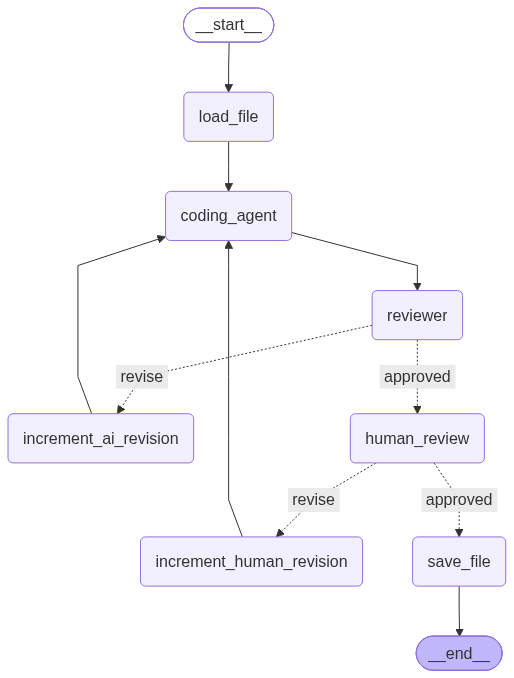

In [28]:
display_graph(
    coding_subgraph,
    Path("coding_subgraph.png")
)

In [29]:
class KnowledgeState(TypedDict):
  user_request: str
  final_answer: str
  messages: Annotated[list[BaseMessage], add_messages]

## External Knowledge Tools

In [30]:
web_search_tool = TavilySearch(
    max_results=3
)

In [31]:
knowledge_tools = [
    search_knowledge_base,
    web_search_tool
]

## Prompt

In [32]:
KNOWLEDGE_SYSTEM_PROMPT = """
You are a software-development research assistant.

Your task is to answer informational questions using
the most appropriate available source.

Available tools:

1. search_knowledge_base
   Use for internal or project-specific information such as:
   - coding standards;
   - software engineering guidelines;
   - testing conventions;
   - architecture rules;
   - error-handling policies;
   - code-review rules;
   - development workflow documentation.

2. web_search
   Use for external, public, historical,
   recent, or changing information.

Choose the tool that best matches the question.

Do not use web search when the question is specifically
about internal project documentation.

After gathering sufficient information,
provide a clear synthesized answer to the user's question.
"""

In [33]:
knowledge_agent_executor = create_agent(
    model=coding_model,
    tools=knowledge_tools,
    system_prompt=KNOWLEDGE_SYSTEM_PROMPT
)

## Knowledge Agent

In [34]:
def knowledge_agent(state: KnowledgeState):
    result = knowledge_agent_executor.invoke({
        "messages": [
            HumanMessage(content = state["user_request"])
        ]
    })

    final_message = result["messages"][-1]

    return {
        "messages": result["messages"],
        "final_answer": final_message.content
    }

## Build Knowledge Subgraph

In [35]:
knowledge_builder = StateGraph(KnowledgeState)

knowledge_builder.add_node('knowledge_agent', knowledge_agent)

knowledge_builder.add_edge(START, "knowledge_agent")

knowledge_builder.add_edge("knowledge_agent", END)

knowledge_subgraph = knowledge_builder.compile()

## Visualization

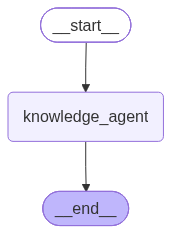

In [36]:
display_graph(knowledge_subgraph,Path("knowledge_subgraph.png"))

## Main Workflow

## Main State

In [37]:
class MainState(TypedDict):
    user_request: str
    intent: Literal['chat', 'knowledge', 'code']
    task_type: Literal['create', 'modify'] | None
    file_path: str
    file_path_error: str
    original_content: str
    proposed_content: str
    review: dict | None
    human_feedback: str
    ai_revision_count: int
    human_revision_count: int

    final_answer: str
    messages: Annotated[list[BaseMessage], add_messages]

## Classification Schema

In [38]:
class ClassificationResult(BaseModel):
    intent: Literal['chat', 'knowledge', 'code'] = Field(
        description = "The type of the user's request."
    )

    task_type: Literal['create', 'modify'] | None = Field(
        default = None,
        description="For coding requests, whether code should be created or an existing file modified."
    )

    file_path: str = Field(
        default = "",
    )

## Classifier Agent

In [39]:
classifier_model = coding_model.with_structured_output(ClassificationResult)

CLASSIFIER_SYSTEM_PROMPT = """
Classify the user's request into exactly one category:

chat:
General conversation that does not require
external research or code generation.

knowledge:
An informational or research question that
should be handled by the knowledge workflow.

code:
A request to create software code or modify
an existing code file.

For code requests:
- task_type="create" when new code should be generated;
- task_type="modify" when an existing file should be changed;
- extract file_path only when the user explicitly provides one.

Programming language does not affect the intent classification.

Return only the structured classification.
"""

def classifier(state: MainState):
    classification = classifier_model.invoke([
        SystemMessage(content=CLASSIFIER_SYSTEM_PROMPT),
        HumanMessage(content=state["user_request"])
    ])

    return {
        "intent": classification.intent,
        "task_type": classification.task_type,
        "file_path": classification.file_path
    }

## Chat Agent

In [40]:
CHAT_SYSTEM_PROMPT = """
You are a helpful conversational assistant.

Respond naturally and concisely to general user messages.
Do not use coding tools or knowledge retrieval for simple conversation.
"""

def chat_agent(state: MainState):
    conversation = [
        SystemMessage(content=CHAT_SYSTEM_PROMPT),
        *state.get("messages", []),
        HumanMessage(content=state["user_request"])
    ]

    response = coding_model.invoke(conversation)

    return {
        "final_answer": response.content,
        "messages": [
            HumanMessage(content = state['user_request']),
            response
        ]
    }

## Missing File Path HITL

When the classifier identifies a code modification request but the user has no provided a file path, the workflow pauses and asks the user for the missing information.

The workflow is later resumed using `Command(resume=...)`.

In [41]:
def request_file_path(state: MainState):
    error = state.get("file_path_error", "")

    if error:
        message = error
    else:
        message = (
            "Please provide the path of the file "
            "you want to modify."
        )

    file_path = interrupt({
        "message": message,
        "workflow_status": "waiting_for_file_path"
    })

    return {
        "file_path": str(file_path).strip()
    }

In [42]:
def validate_file_path(state: MainState):
    file_path = state.get("file_path", "").strip()

    if not file_path:
        return {"file_path": "", "file_path_error": "File path cannot be empty."}

    path = Path(file_path)

    if not path.exists():
        return {
            "file_path": "",
            "file_path_error": (
                f"File '{file_path}' was not found. "
                "Please provide a valid file path."
            )
        }

    if not path.is_file():
        return {
            "file_path": "",
            "file_path_error": (
                f"'{file_path}' is not a file. "
                "Please provide the path to a file."
            )
        }

    return {"file_path": file_path, "file_path_error": ""}

def route_after_file_validation(state: MainState):
    if state.get("file_path"):
        return "valid"

    return "invalid"

## Main Routing

the classifier determines the request type, while a deterministic routing function selects the corresponding workflow.

A modification request without a file path is routed to the missing-information HITL node before entering the coding subgraph

In [43]:
def route_after_classifier(state: MainState):
    intent = state["intent"]

    if intent == "chat":
        return "chat"

    if intent == "knowledge":
        return "knowledge"

    if intent == "code":
        if (state["task_type"] == "modify" and not state.get("file_path")):
            return "missing_file_path"

        return "code"

    raise ValueError(f"Unsupported intent: {intent}")

## Build Main Graph

The main graph orchestrates the three application paths:

- **Chat**: conversational agent
- **Knowledge**: knowledge and RAG subgraph
- **Code**: coding and review subgraph

The parent graph owns the checkpointer. This allows workflow state to persist accross interruptions and enables human-in-the-loop resume behavior.

In [44]:
main_builder = StateGraph(MainState)

main_builder.add_node('classifier', classifier)
main_builder.add_node('chat_agent', chat_agent)
main_builder.add_node('knowledge_workflow', knowledge_subgraph)
main_builder.add_node('coding_workflow', coding_subgraph)
main_builder.add_node('request_file_path', request_file_path)
main_builder.add_node('validate_file_path', validate_file_path)

main_builder.add_edge(START, "classifier")

main_builder.add_conditional_edges(
    "classifier",
    route_after_classifier,
    {
        "chat": "chat_agent",
        "knowledge": "knowledge_workflow",
        "code": "coding_workflow",
        "missing_file_path": "request_file_path"
    }
)

# missing file path
main_builder.add_edge("request_file_path", "validate_file_path")

main_builder.add_conditional_edges(
    "validate_file_path",
    route_after_file_validation,
    {
        "valid": "coding_workflow",
        "invalid": "request_file_path"
    }
)

main_builder.add_edge("chat_agent", END)
main_builder.add_edge("knowledge_workflow", END)
main_builder.add_edge("coding_workflow", END)

main_checkpointer = InMemorySaver()

main_graph = main_builder.compile(
    checkpointer = main_checkpointer,
    #debug = True
)

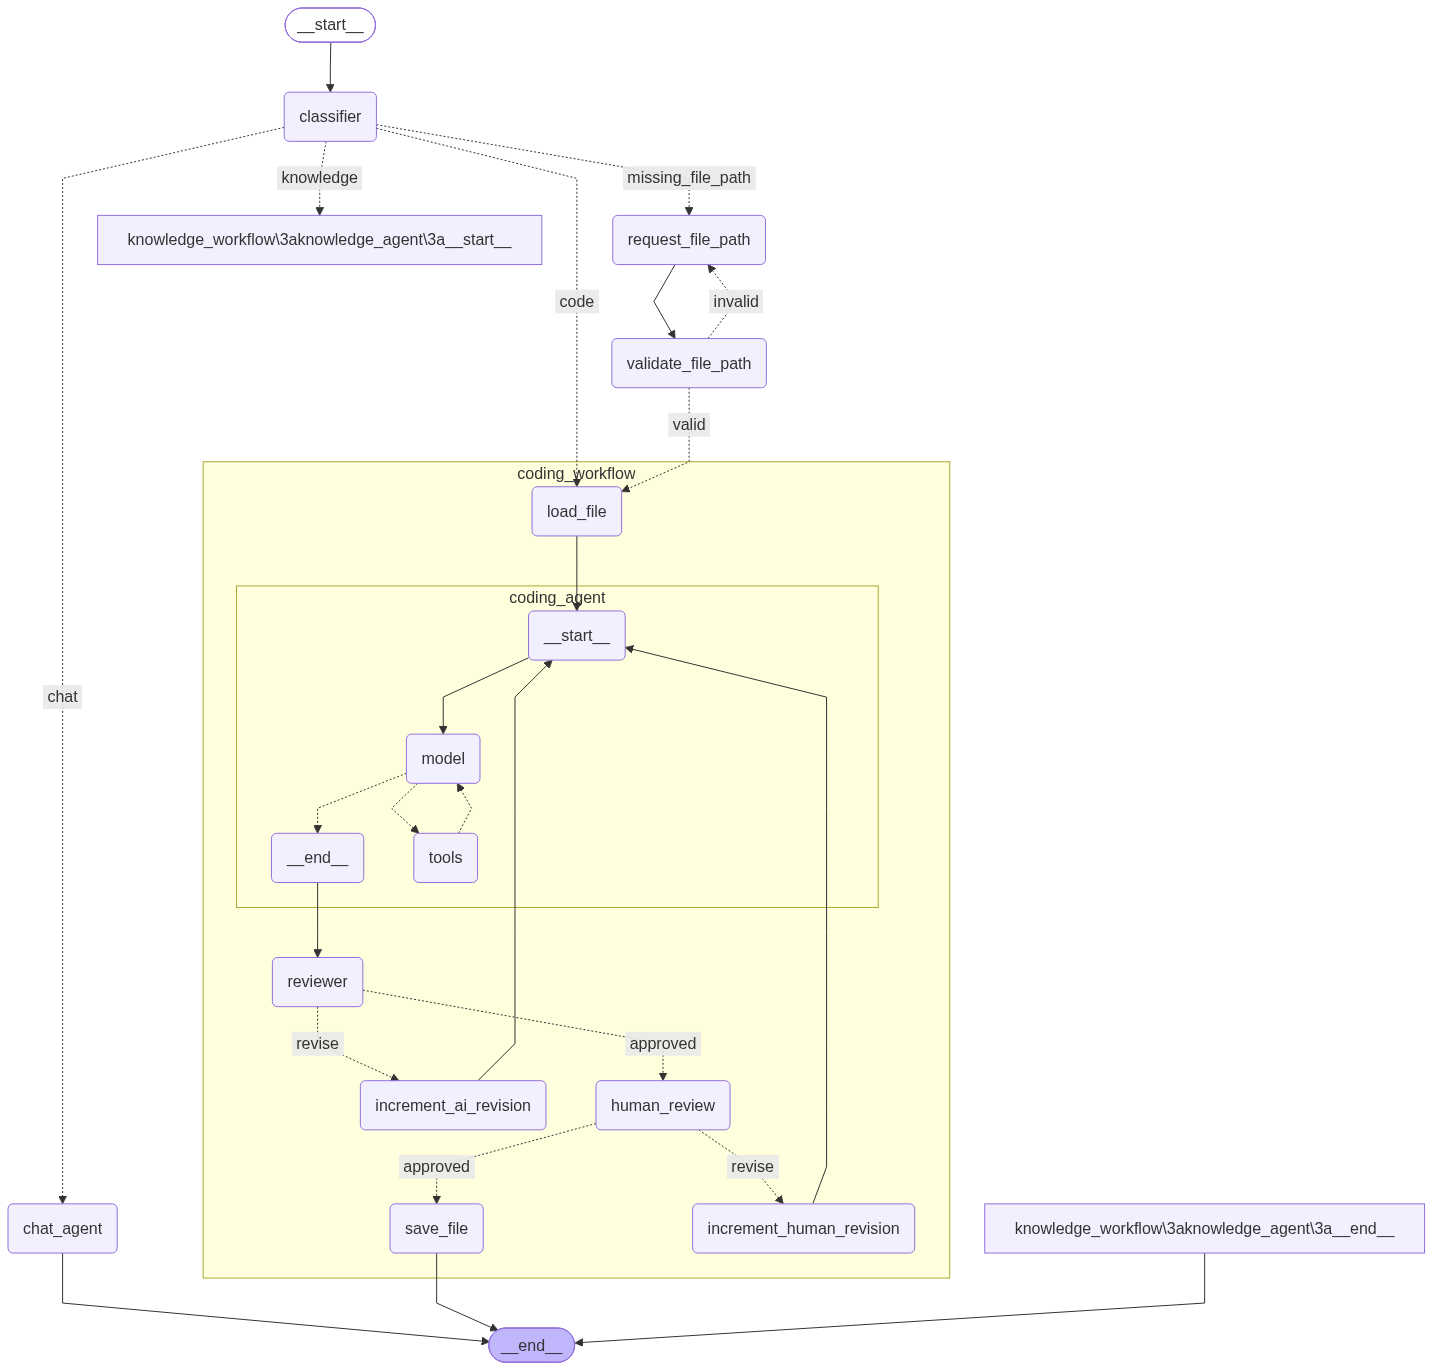

In [45]:
display(Image(main_graph.get_graph(xray=True).draw_mermaid_png()))

In [46]:
def get_human_input(interrupts: List[Interrupt]) -> str:
    interrupt_value = interrupts[0].value

    workflow_status = interrupt_value.get(
        "workflow_status"
    )

    if workflow_status == "waiting_for_file_path":
        return input(
            "\nEnter file path: "
        ).strip()

    if workflow_status == "pending_human_approval":
        return input(
            "\nType 'approve' or provide revision feedback: "
        ).strip()

    return input(
        "\nProvide input: "
    ).strip()

## Workflow Execution

In [47]:
def execute_workflow(
    user_request: str,
    thread_id: str = "default"
):
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    result = main_graph.invoke(
        {
            "user_request": user_request,
            "intent": "chat",
            "task_type": None,
            "file_path": "",
            "file_path_error": "",
            "proposed_content": "",
            "review": None,
            "human_feedback": "",
            "ai_revision_count": 0,
            "human_revision_count": 0,
            "final_answer": "",
            "messages": []
        },
        config=config
    )

    while "__interrupt__" in result:
        interrupts = result["__interrupt__"]

        # 1. Show interrupt
        print_interrupts(interrupts)

        # 2. Ask the human
        human_decision = get_human_input(interrupts)

        # 3. Resume SAME graph + SAME thread
        result = main_graph.invoke(
            Command(
                resume=human_decision
            ),
            config=config
        )

    return result

## Test Cases

In [48]:
create_result = execute_workflow(
    user_request=(
        "Create a C# method that calculates "
        "the factorial of a non-negative integer "
        "following our internal development guidelines."
    ),
    thread_id="test-csharp-rag"
)

print(create_result["final_answer"])


Type 'approve' or provide revision feedback: approve
Workflow completed. The proposed code was approved.


In [49]:
test_file = Path("/content/example.py")

test_file.write_text(
    """
      def divide(a, b):
      return a / b
    """,
    encoding="utf-8"
)

print(test_file.read_text())


      def divide(a, b):
      return a / b
    


In [50]:
modify_result = execute_workflow(
    user_request=(
        "Modify /content/example.py so that division by zero "
        "is handled according to our internal development guidelines. "
        "Preserve the existing function."
    ),
    thread_id="test-modify-python"
)

print(modify_result["final_answer"])


Type 'approve' or provide revision feedback: approve
Workflow completed. Success: File '/content/example.py' was updated.


In [51]:
print(
    Path("/content/example.py").read_text(
        encoding="utf-8"
    )
)

def divide(a: float, b: float) -> float:
    """Divide a by b."""
    if b == 0:
        raise ZeroDivisionError("Cannot divide by zero.")
    return a / b


## Test 1 - Chat

In [52]:
chat_result = execute_workflow(
    user_request=(
        "Hello! How are you?"
    ),
    thread_id="test-chat"
)

print(
    chat_result["final_answer"]
)

Hello! I’m doing well, thank you. How are you?


## Test 2 - Internal Knowledge / RAG

In [53]:
rag_result = execute_workflow(
    user_request=(
        "According to our internal "
        "development guidelines, how "
        "should errors be handled?"
    ),
    thread_id="test-internal-rag-2"
)

print(
    rag_result["final_answer"]
)

According to the internal guidelines:

- **Do not silently ignore failures.**
- **Use specific exception types** rather than generic exceptions such as `Exception`.
- **Validate inputs at appropriate boundaries**, using suitable argument exceptions where applicable.
- **Catch exceptions only when you can handle them, add meaningful context, or translate them at an appropriate boundary.** Don’t catch merely to suppress.
- **Provide useful, contextual error messages.**
- **Never include secrets** such as passwords, API keys, or tokens in errors.
- **Preserve the project’s existing error-handling conventions**, including consistent use of checked versus unchecked exceptions where relevant.
- At intentional broad boundaries, broad catches may be appropriate, but they should not be the default.


## Test 3 - External Knowledge

In [54]:
external_result = execute_workflow(
    user_request=(
        "Who was Ada Lovelace and "
        "what is she known for?"
    ),
    thread_id="test-external-knowledge"
)

print(
    external_result["final_answer"]
)

Ada Lovelace (1815–1852), born Augusta Ada Byron, was an English mathematician and writer. She is best known for her work on Charles Babbage’s proposed **Analytical Engine**, an early design for a general-purpose mechanical computer.

In 1843, she published notes describing an algorithm for the machine to calculate Bernoulli numbers. Because this was one of the earliest published computer programs, she is often called **the world’s first computer programmer**. She also understood that computers could potentially manipulate symbols, music, and ideas—not just perform arithmetic.


In [55]:
print(
    web_search_tool.invoke({
        "query": "Who was Ada Lovelace and what is she known for?"
    })
)

{'query': 'Who was Ada Lovelace and what is she known for?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/Ada_Lovelace', 'title': 'Ada Lovelace', 'content': 'Augusta Ada King, Countess of Lovelace (née Byron; 10 December 1815 – 27 November 1852), also known as Ada Lovelace, was an English mathematician and writer chiefly known for work on Charles Babbage\'s proposed mechanical general-purpose computer, the analytical engine. She was the first to recognise the machine had applications beyond pure calculation. Lovelace is often considered the first computer programmer. [...] | Augusta Ada King, Countess of Lovelace, daguerrotype portrait circa 1843 Daguerreotype of Lovelace (c.\u20091843) |\n| Born | Augusta Ada Byron  (1815-12-10)10 December 1815  London, England |\n| Died | 27 November 1852(1852-11-27) (aged 36)  Marylebone, London, England |\n| Resting place | Church of St Mary Magdalene, Hucknall, Nottingham, England |\

In [56]:
print(
    web_search_tool.invoke({
        "query": "Ada Lovelace"
    })
)

{'query': 'Ada Lovelace', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/Ada_Lovelace', 'title': 'Ada Lovelace', 'content': 'From Wikipedia, the free encyclopedia\n\nEnglish mathematician (1815–1852)\n\n \n\nFor the computer microarchitecture, see Ada Lovelace (microarchitecture) "Ada Lovelace (microarchitecture)").\n\n| The Right Honourable  The Countess of Lovelace | [...] The Cardano cryptocurrency platform "Cardano (blockchain platform)"), launched in 2017, uses Ada as the name for the cryptocurrency and Lovelace as the smallest sub-unit of an Ada.\n Ada, an artwork incorporating artificial intelligence house at Microsoft\'s Building 99.\n In 2021, the code name of Nvidia\'s GPU architecture in its RTX 4000 series is Ada Lovelace "Ada Lovelace (microarchitecture)"). It is the first Nvidia architecture to feature both a first and last name. [...] The 2022 graphics processor microarchitecture from Nvidia is named Ada Love

## Test - Combined Knowledge: Internal RAG + Web Search

In [57]:
combined_knowledge_result = execute_workflow(
    user_request=(
        "According to our internal error-handling guidelines, "
        "how should errors be handled, and compare that with "
        "current general Python exception-handling best practices."
    ),
    thread_id="test-combined-knowledge"
)

print_conversation(combined_knowledge_result["messages"])

print_tool_usage(combined_knowledge_result["messages"])

================================ Human Message =================================

According to our internal error-handling guidelines, how should errors be handled, and compare that with current general Python exception-handling best practices.
================================== Ai Message ==================================
Tool Calls:
  search_knowledge_base (call_KCV8kghhY5tEYU51ABG3brWB)
 Call ID: call_KCV8kghhY5tEYU51ABG3brWB
  Args:
    query: internal error-handling guidelines how errors should be handled exceptions Python
================================= Tool Message =================================
Name: search_knowledge_base

Result 1
          ---------
          ## 6. Python Guidelines

### Style
- Follow common PEP 8 conventions.
- Use snake_case for functions and variables.
- Use PascalCase for classes.
- Prefer useful type hints on public functions.
- Add useful docstrings to public APIs.
- Avoid unused imports.

### Error Handling
- Prefer specific built-in or domain e

## Test 4 - Create Code

In [58]:
csharp_rag_result = execute_workflow(
    user_request=(
        "Create a C# method that validates a user's age. "
        "Follow our internal C# coding, error-handling, "
        "and testing guidelines."
    ),
    thread_id="test-csharp-rag-3"
)

print(csharp_rag_result["final_answer"])

print_conversation(csharp_rag_result["messages"])

print_tool_usage(csharp_rag_result["messages"])


Type 'approve' or provide revision feedback: approve
Workflow completed. The proposed code was approved.
================================ Human Message =================================


        User request:
        Create a C# method that validates a user's age. Follow our internal C# coding, error-handling, and testing guidelines.

        Task type:
        create

        File path:
        

        Original file content:
        
    
        Previous proposed implementation:
        

        Reviewer feedback:
        

        Human feedback:
        
        
================================== Ai Message ==================================
Tool Calls:
  search_knowledge_base (call_haQGNWvoEGxjQAqRXdVaY5sq)
 Call ID: call_haQGNWvoEGxjQAqRXdVaY5sq
  Args:
    query: internal C# coding standards error handling and testing guidelines for validation methods, age validation, exceptions and tests
================================= Tool Message =================================
Name

## Test 5 - Modify + Approve

In [59]:
Path("/content/example.py").write_text(
    """
    def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

modify_result = execute_workflow(
    user_request=(
        "Modify /content/example.py "
        "to handle division by zero."
    ),
    thread_id="test-modify"
)

print(
    modify_result["final_answer"]
)


Type 'approve' or provide revision feedback: yes
Workflow completed. Success: File '/content/example.py' was updated.


In [60]:
print(
    Path(
        "/content/example.py"
    ).read_text(
        encoding="utf-8"
    )
)

def divide(a, b):
    if b == 0:
        raise ZeroDivisionError("Cannot divide by zero")
    return a / b


## Test 6 - Revision

In [61]:
Path("/content/example_revision.py").write_text(
    """def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

39

In [62]:
revision_result = execute_workflow(
    user_request=(
        "Modify /content/example_revision.py "
        "to handle division by zero."
    ),
    thread_id="test-revision"
)

print(revision_result["final_answer"])

#Raise ZeroDivisionError explicitly and add a descriptive docstring.


Type 'approve' or provide revision feedback: Raise ZeroDivisionError explicitly and add a descriptive docstring.



Type 'approve' or provide revision feedback: yes
Workflow completed. Success: File '/content/example_revision.py' was updated.


## Missing Path

In [63]:
Path("/content/missing_path_example.py").write_text(
    """def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

39

In [64]:
missing_path_result = execute_workflow(
    user_request=(
        "Modify the existing divide function "
        "so that it handles division by zero."
    ),
    thread_id="test-missing-path"
)

print(
    missing_path_result["final_answer"]
)


Enter file path: yes



Enter file path: das



Enter file path: /content/example.py



Type 'approve' or provide revision feedback: yes
Workflow completed. Success: File '/content/example.py' was updated.


In [65]:
memory_result_1 = execute_workflow(
    user_request = (
        "My name is Nikol and my favorite "
        "programming language is C#."
    ),
    thread_id = "test-memory"
)

print(memory_result_1["final_answer"])

Nice to meet you, Nikol! C# is a versatile language—great for web apps, games with Unity, desktop software, and more.


In [66]:
memory_result_2 = execute_workflow(
    user_request=(
        "What is my name and what is my "
        "favorite programming language?"
    ),
    thread_id="test-memory"
)

print(memory_result_2["final_answer"])

Your name is Nikol, and your favorite programming language is C#.


## Test - Different thread doesn't share memory

In [67]:
isolated_memory_result = execute_workflow(
    user_request=(
        "What is my name and what is my "
        "favorite programming language?"
    ),
    thread_id="test-memory-new-thread"
)

print(isolated_memory_result["final_answer"])

I don’t know your name or your favorite programming language—you haven’t told me yet.
